Saving Housing.csv to Housing.csv
First 5 Rows
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset Shape
(506, 14)

Column Names
Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   N

/tmp/ipykernel_919/3947883261.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)


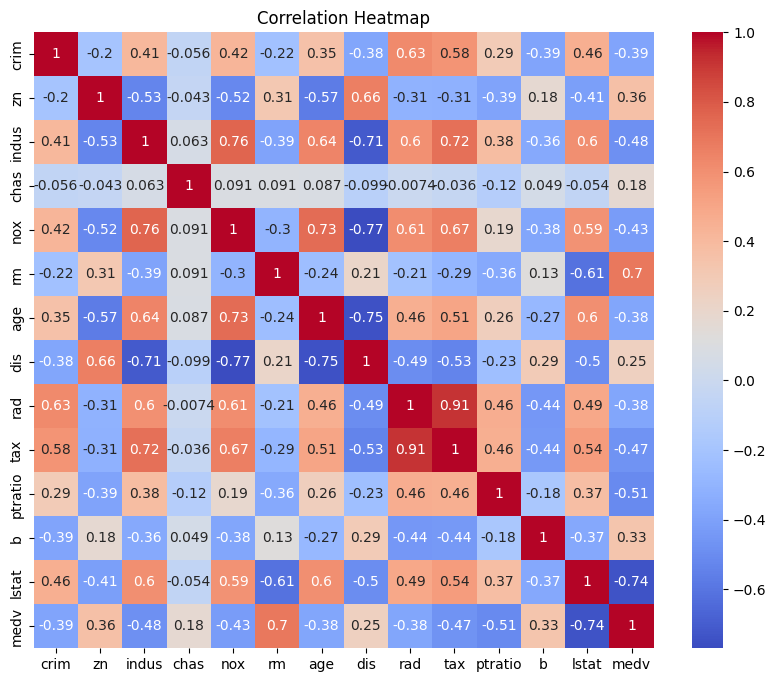


Training Data Shape
(404, 13)

Testing Data Shape
(102, 13)

Model Trained Successfully!

First 10 Predictions
   Actual Price  Predicted Price
0          23.6        28.996724
1          32.4        36.025565
2          13.6        14.816944
3          22.8        25.031979
4          16.1        18.769880
5          20.0        23.254429
6          17.8        17.662538
7          14.0        14.341190
8          19.6        23.013207
9          16.8        20.632456

Mean Squared Error (MSE): 24.291119474973478
R² Score: 0.6687594935356326


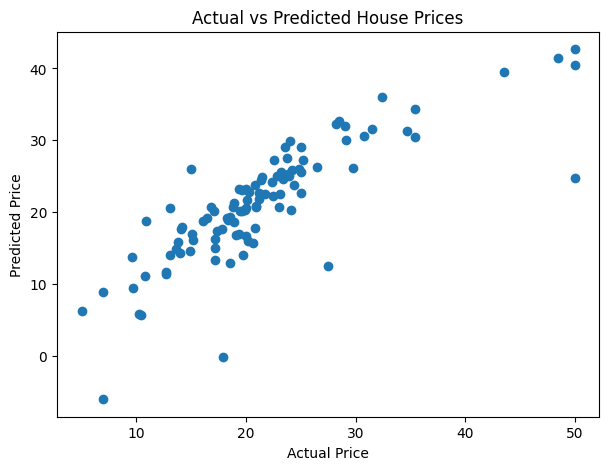

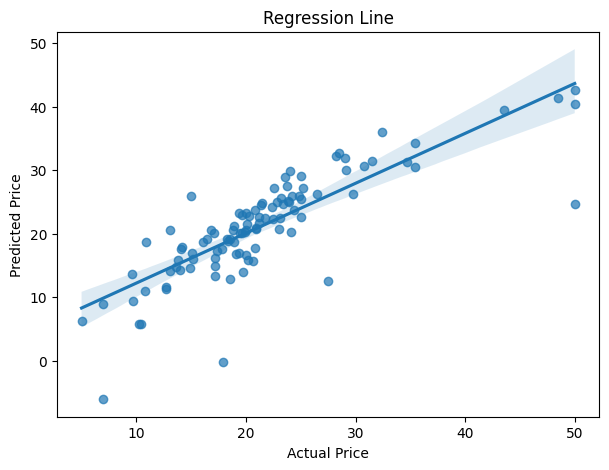

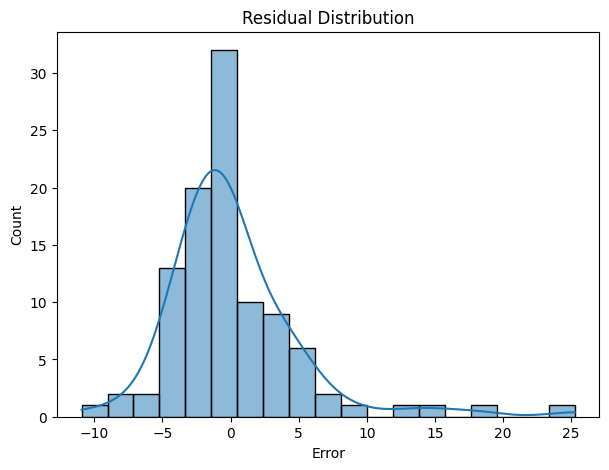


Prediction file saved successfully!

Task 02 Completed Successfully!


In [ ]:
# ==========================================================
# TASK 02 - LINEAR REGRESSION MODEL
# House Price Prediction using Python
# ==========================================================

# ----------------------------
# Step 1: Import Libraries
# ----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------
# Step 2: Upload Dataset
# ----------------------------

uploaded = files.upload()

# ----------------------------
# Step 3: Load Dataset
# ----------------------------

df = pd.read_csv("Housing.csv")

# ----------------------------
# Step 4: Explore Dataset
# ----------------------------

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# ----------------------------
# Step 5: Handle Missing Values
# ----------------------------

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column].fillna(df[column].median(), inplace=True)

# ----------------------------
# Step 6: Remove Duplicates
# ----------------------------

df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning")
print(df.shape)

# ----------------------------
# Step 7: Correlation Heatmap
# ----------------------------

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# ----------------------------
# Step 8: Select Features
# ----------------------------

# MEDV is the target (House Price)

X = df.drop("medv", axis=1)

y = df["medv"]

# ----------------------------
# Step 9: Split Dataset
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape")
print(X_train.shape)

print("\nTesting Data Shape")
print(X_test.shape)

# ----------------------------
# Step 10: Train Model
# ----------------------------

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

# ----------------------------
# Step 11: Predict Prices
# ----------------------------

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions")

predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(predictions.head(10))

# ----------------------------
# Step 12: Evaluate Model
# ----------------------------

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE):", mse)

print("R² Score:", r2)

# ----------------------------
# Step 13: Scatter Plot
# ----------------------------

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

# ----------------------------
# Step 14: Regression Line
# ----------------------------

plt.figure(figsize=(7,5))

sns.regplot(x=y_test,
            y=y_pred,
            scatter_kws={"alpha":0.7})

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Regression Line")

plt.show()

# ----------------------------
# Step 15: Residual Distribution
# ----------------------------

residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.histplot(residuals,
             kde=True)

plt.title("Residual Distribution")

plt.xlabel("Error")

plt.show()

# ----------------------------
# Step 16: Save Predictions
# ----------------------------

predictions.to_csv("Predicted_House_Prices.csv", index=False)

print("\nPrediction file saved successfully!")

print("\nTask 02 Completed Successfully!")